# HamLib → Azure QDK vs. Qualtran: Multi-Hamiltonian Comparison

Runs Azure and Qualtran resource estimation for **multiple HamLib Hamiltonians**
and generates a combined 12-subplot visualization (6 metrics × 2 x-axes).

## Workflow
```
Define Hamiltonians
  → Load/build circuits (QASM cache)
  → Run estimators  (or load cached CSVs)
  → Save per-Hamiltonian comparison CSVs
  → Combine results
  → Save combined CSV
  → Generate 12-subplot figure
```

**Caching**: set `SKIP_CACHED = True` to skip estimation for Hamiltonians
whose per-Hamiltonian CSV already exists under `data/comparisons/`.
Set to `False` to re-run all estimators.

## Imports

In [1]:
import sys, os
import pathlib

# Locate repo root by walking up until we find the package directory
_search = pathlib.Path.cwd()
for _ in range(8):
    if (_search / "resourceEstimationPipeline").is_dir():
        REPO_ROOT = str(_search)
        break
    _search = _search.parent
else:
    REPO_ROOT = str(pathlib.Path.cwd())

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Notebook output directory — results go here (under group subdirs), QASM cache stays in data/
try:
    NB_DIR = pathlib.Path(__vsc_ipynb_file__).parent.resolve()
except NameError:
    NB_DIR = pathlib.Path.cwd()

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4g}".format)

from resourceEstimationPipeline.config import (
    PipelineConfig, HamlibConfig, EvolutionConfig,
    TranspileConfig, AzureConfig, QualtranConfig,
)
from resourceEstimationPipeline.compare.multi_ham import (
    run_multi_hamiltonian,
    save_combined, load_combined,
    save_comparison, load_comparison,
    COMPARISON_COLUMNS,
)
from resourceEstimationPipeline.compare.plotting import plot_multi_ham_comparison

print(f"REPO_ROOT : {REPO_ROOT}")
print(f"NB_DIR    : {NB_DIR}")
print("Imports OK")

REPO_ROOT : /Users/kevinli/Documents/resourceEstimation
NB_DIR    : /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib
Imports OK


## Configuration

All estimator parameters live in `base_cfg`.  
Per-Hamiltonian parameters (`hdf5_path`, `key_index`) are in `HAMILTONIANS`.

In [2]:
# ── Estimation flags ──────────────────────────────────────────────────────────
RUN_AZURE     = True   # set False to skip Azure estimation
RUN_QUALTRAN  = True   # set False to skip Qualtran estimation
SKIP_CACHED   = True   # True → load CSV if already saved; False → re-run

# ── Hamiltonians to process ───────────────────────────────────────────────────
# Each entry: {"hdf5_path": ..., "key_index": int} or {"key": "dataset_key"}
# Optional "group" overrides the auto-detected problem type label.
HAMILTONIANS = [
    # Fermi-Hubbard 1D (FH_D-1.hdf5)
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "fermihubbard", "FH_D-1.hdf5"),
        "key_index": 396,
    },
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "fermihubbard", "FH_D-1.hdf5"),
        "key_index": 704,
    },
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "fermihubbard", "FH_D-1.hdf5"),
        "key_index": 39,
    },
    # Bose-Hubbard 1D (BH_D-1_d-4.hdf5)
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "bosehubbard", "BH_D-1_d-4.hdf5"),
        "key_index": 585,
    },
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "bosehubbard", "BH_D-1_d-4.hdf5"),
        "key_index": 30,
    },
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "bosehubbard", "BH_D-1_d-4.hdf5"),
        "key_index": 300,
    },
    # Heisenberg (heis.hdf5)
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "heisenberg", "heis.hdf5"),
        "key_index": 273,
    },
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "heisenberg", "heis.hdf5"),
        "key_index": 14,
    },
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "heisenberg", "heis.hdf5"),
        "key_index": 123,
    },
    {
        "hdf5_path": os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "heisenberg", "heis.hdf5"),
        "key_index": 268,
    },
]

# ── Base estimator configuration ──────────────────────────────────────────────
base_cfg = PipelineConfig(
    evolution=EvolutionConfig(
        evolution_time=1.0,
        synthesis_order=2,
        synthesis_reps=10,
    ),
    transpile=TranspileConfig(
        optimization_level=1,
        seed_transpiler=42,
        rotation_synthesis_enabled=False,
        rotation_synthesis_epsilon=1e-4,
        synthesis_strategy="synth",
        synthesis_method="bqskit",
    ),
    azure=AzureConfig(
        error_budget=0.01,
        error_rate=1e-3,
        gate_time_ns=50.0,
        measurement_time_ns=100.0,
        factory_type="RoundBased",
        slow_down_factors=[1.0],
        optimization_level=1,
        use_graph=True,
        minimize="qubit_hours",
        pareto_index=0,
    ),
    qualtran=QualtranConfig(
        data_d=23,
        phys_err=1e-3,
        error_budget=0.01,
        data_block="fast",
        factory_type="15to1",
        n_factories=10,
        use_gidney_fowler=False,
        use_beverland=True,
        use_azure_parameters=False,
        optimize_factory=True,
        optimize_factory_d_max=50,
        pareto_index=0,
    ),
)

print(f"{len(HAMILTONIANS)} Hamiltonians configured.")
for i, spec in enumerate(HAMILTONIANS):
    from resourceEstimationPipeline.compare.multi_ham import _detect_group
    grp = spec.get("group") or _detect_group(spec["hdf5_path"])
    print(f"  [{i:2d}] [{grp}]  {os.path.basename(spec['hdf5_path'])}  "
          f"idx={spec.get('key_index')}  key={spec.get('key')}")

10 Hamiltonians configured.
  [ 0] [fermihubbard]  FH_D-1.hdf5  idx=396  key=None
  [ 1] [fermihubbard]  FH_D-1.hdf5  idx=704  key=None
  [ 2] [fermihubbard]  FH_D-1.hdf5  idx=39  key=None
  [ 3] [bosehubbard]  BH_D-1_d-4.hdf5  idx=585  key=None
  [ 4] [bosehubbard]  BH_D-1_d-4.hdf5  idx=30  key=None
  [ 5] [bosehubbard]  BH_D-1_d-4.hdf5  idx=300  key=None
  [ 6] [heisenberg]  heis.hdf5  idx=273  key=None
  [ 7] [heisenberg]  heis.hdf5  idx=14  key=None
  [ 8] [heisenberg]  heis.hdf5  idx=123  key=None
  [ 9] [heisenberg]  heis.hdf5  idx=268  key=None


## Run estimators (or load cached results)

For each Hamiltonian:
1. Load/build circuit (QASM cache — fast)
2. If `SKIP_CACHED=True` and a per-Hamiltonian CSV exists, load it instead of running estimators
3. Otherwise run Azure and/or Qualtran, save CSV

Individual failures do not abort the loop.

In [3]:
combined_df = run_multi_hamiltonian(
    ham_specs=HAMILTONIANS,
    base_cfg=base_cfg,
    run_azure=RUN_AZURE,
    run_qualtran=RUN_QUALTRAN,
    skip_cached=SKIP_CACHED,
    out_dir=NB_DIR,
)

print(f"\nTotal rows collected: {len(combined_df)}")
if not combined_df.empty:
    print(combined_df.groupby(["group", "ham_key", "estimator"])[["total_qubits", "runtime", "t_count"]].first().to_string())


[1/10] [fermihubbard]  idx=396  key=None
[1/6] Loaded Hamiltonian: HamiltonianData(key='fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk', nqubits=4, n_terms=4, one_norm=2.0)
[2/6] Cache hit (passthrough) — skipping evolution and synthesis.
[cache] Loaded ← /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/data/hamlib/condensedmatter/fermihubbard/FH_D-1/passthrough_396.qasm
[3/6] (skipped — loaded from passthrough cache): depth=1110, T=0, Rz=450, Clifford=1020
[4/6] Azure QDK: phys_qubits=68,015, runtime=0.0035s
[5/6] Qualtran: phys_qubits=286,780, runtime=0.0126s
[6/6] Comparison: 26 shared metrics, 16 numeric differences.
  Side-by-side → /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib/fermihubbard/comparison_fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk.csv
  Summary      → /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib/fermihubbard/summary_fh-graph-1D-

## Save combined results

Saves to `data/comparisons/all_comparisons.csv`.  
The plots can be regenerated from this file without re-running estimators.

In [4]:
if not combined_df.empty:
    combined_path = save_combined(combined_df, out_dir=NB_DIR)
    print(f"Combined CSV → {combined_path}")
else:
    print("No results to save — check estimator errors above.")

Combined CSV → /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib/all_comparisons.csv


## (Optional) Load from combined CSV

Run this cell instead of the estimation cells above to regenerate plots
from previously saved results.

In [5]:
# Uncomment to load without re-running estimators:
# combined_df = load_combined(out_dir=NB_DIR)
# if combined_df is None:
#     print("No combined CSV found — run estimators first.")
# else:
#     print(f"Loaded {len(combined_df)} rows from combined CSV.")
#     display(combined_df)
print("(cell skipped — using in-memory combined_df from estimation step)")

(cell skipped — using in-memory combined_df from estimation step)


## Inspect combined DataFrame

In [6]:
if combined_df.empty:
    print("No data — nothing to display.")
else:
    from IPython.display import display
    display(combined_df[COMPARISON_COLUMNS])

,group,ham_key,hdf5_path,key_index,nqubits,estimator,rz_count,logical_qubits,spacetime,compute_qubits,factory_qubits,total_qubits,runtime,t_count,estimator_name
0,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5,396,4,Azure,450,4,238.3,3615,64400,68015,0.003504,5400,"Azure QDK (err_rate=1e-03, budget=0.01)"
1,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5,396,4,Qualtran,450,4,3609,5070,281710,286780,0.01258,3080,"Qualtran (d=13, p=1e-03)"
2,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-0_enc-parity,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5,704,10,Azure,1890,10,2156,10110,106040,116150,0.01856,24570,"Azure QDK (err_rate=1e-03, budget=0.01)"
3,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-0_enc-parity,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5,704,10,Qualtran,1890,10,2.576e+04,13500,401790,415290,0.06204,14100,"Qualtran (d=15, p=1e-03)"
4,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5,39,20,Azure,14250,20,1.078e+04,18198,163880,182078,0.0592,213750,"Azure QDK (err_rate=1e-03, budget=0.01)"
5,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5,39,20,Qualtran,14250,20,2.637e+05,31212,550494,581706,0.4533,103020,"Qualtran (d=17, p=1e-03)"
6,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-10_enc-gray_d-4,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/bosehubbard/BH_D-1_d-4.hdf5,585,10,Azure,69990,10,3.745e+04,13470,148280,161750,0.2315,1049850,"Azure QDK (err_rate=1e-03, budget=0.01)"
7,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-10_enc-gray_d-4,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/bosehubbard/BH_D-1_d-4.hdf5,585,10,Qualtran,69990,10,1.195e+06,21660,524280,545940,2.189,471240,"Qualtran (d=19, p=1e-03)"
8,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-10_enc-gray_d-4,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/bosehubbard/BH_D-1_d-4.hdf5,30,20,Azure,157290,20,1.004e+05,24246,148280,172526,0.5822,2673930,"Azure QDK (err_rate=1e-03, budget=0.01)"
9,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-26_U-10_enc-gray_d-4,/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/bosehubbard/BH_D-1_d-4.hdf5,300,52,Azure,436650,52,7.486e+05,72702,337044,409746,1.827,7423050,"Azure QDK (err_rate=1e-03, budget=0.01)"


## 12-subplot comparison figure

**Left column** — x: Rz count  
**Right column** — x: Logical qubits  

**Rows** (top→bottom): Spacetime, Compute qubits, Factory qubits, Total qubits, Runtime, T count  

Each point = one Hamiltonian. Lines connect points belonging to the same estimator,
sorted by x-value.

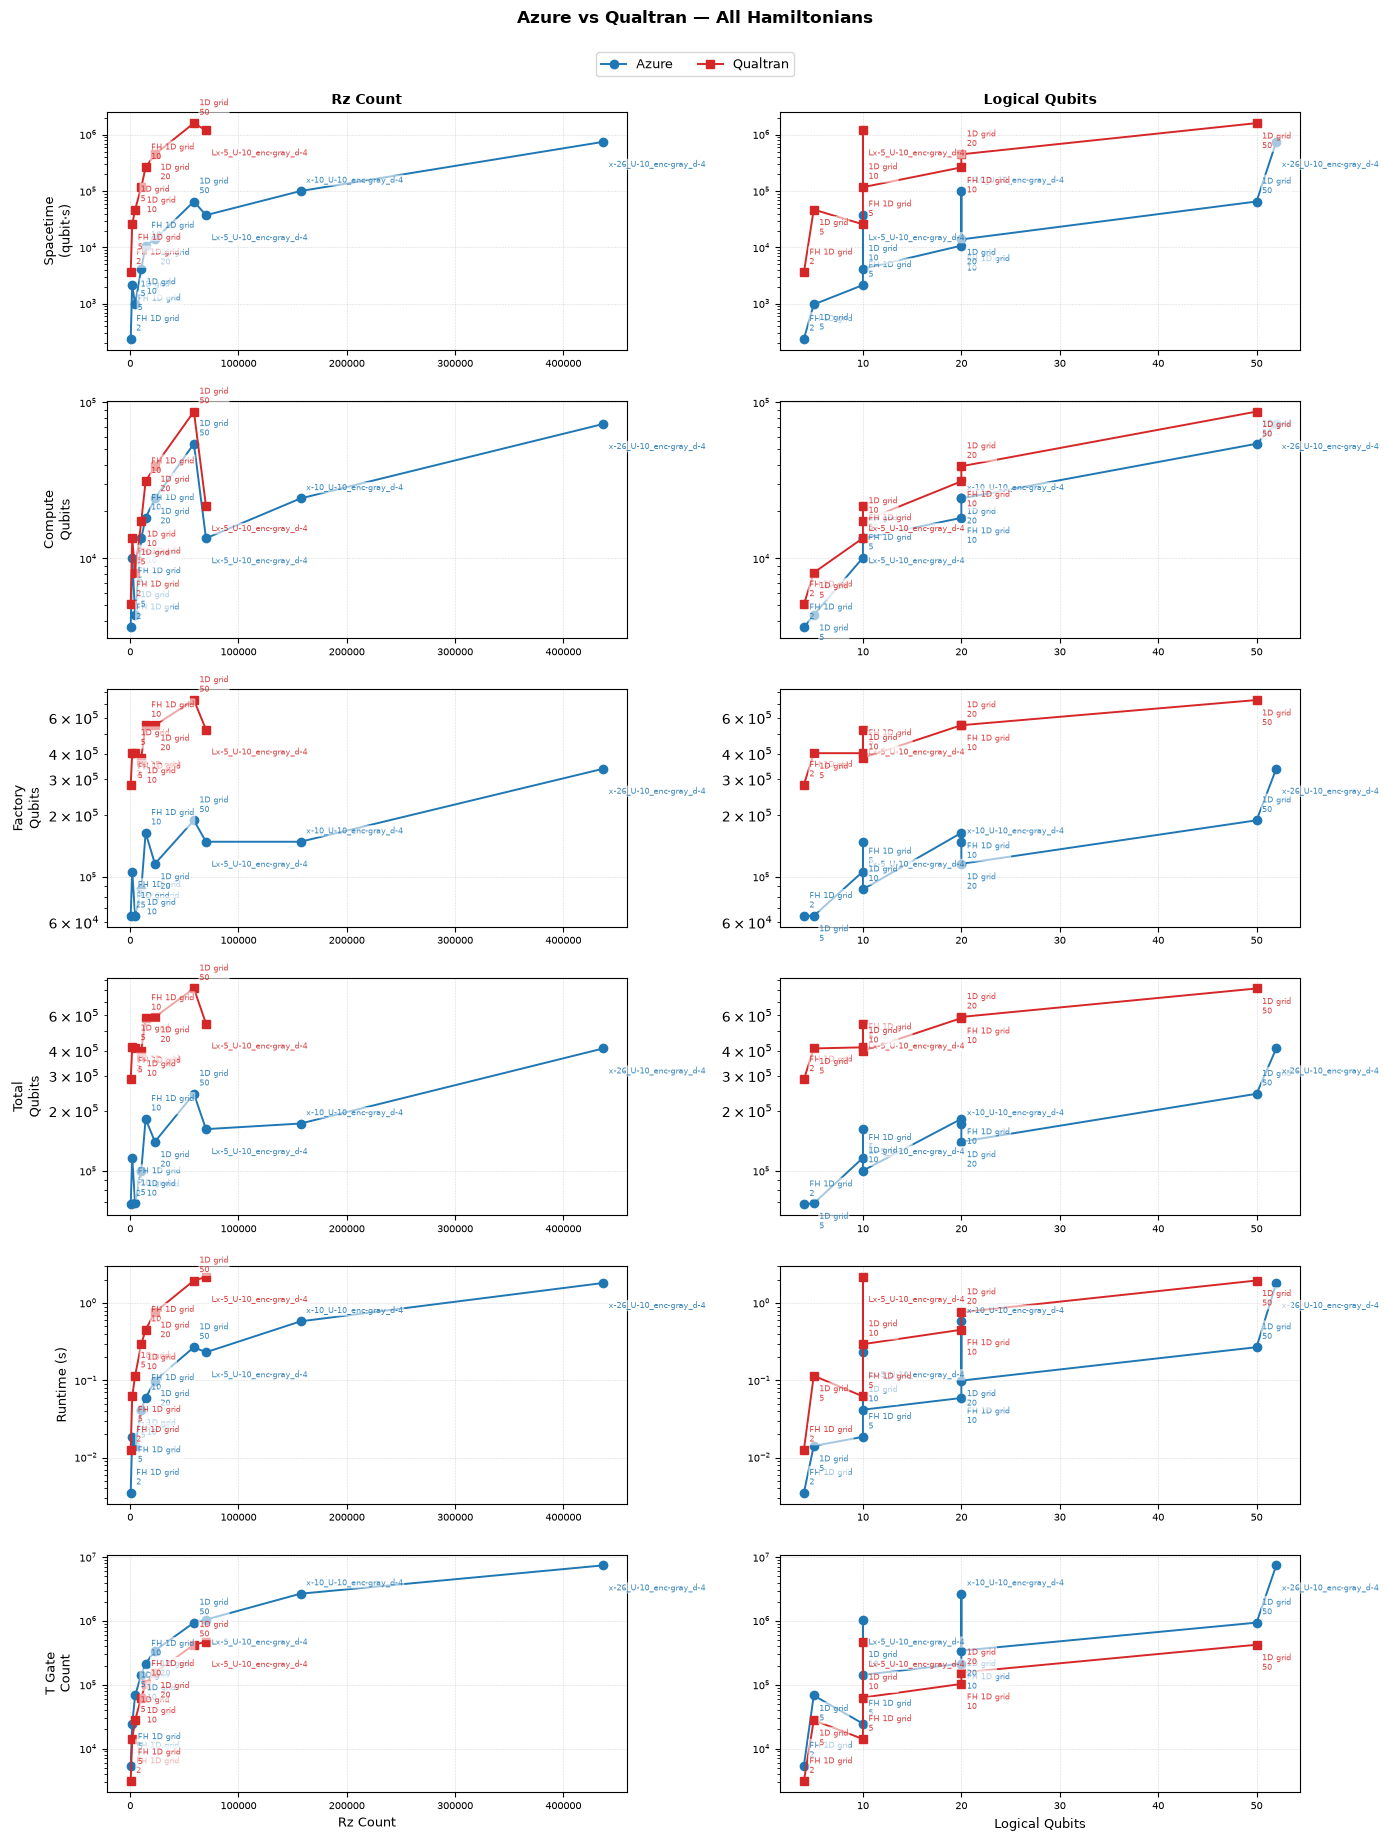

Figure saved → /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib/all_hamiltonians.png


In [7]:
# All-Hamiltonians combined plot
if combined_df.empty:
    print("No data to plot.")
else:
    fig = plot_multi_ham_comparison(
        combined_df,
        figsize=(14, 18),
        title="Azure vs Qualtran — All Hamiltonians",
        log_y=True,
        annotate_points=True,
    )
    plot_path = NB_DIR / "all_hamiltonians.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved → {plot_path}")

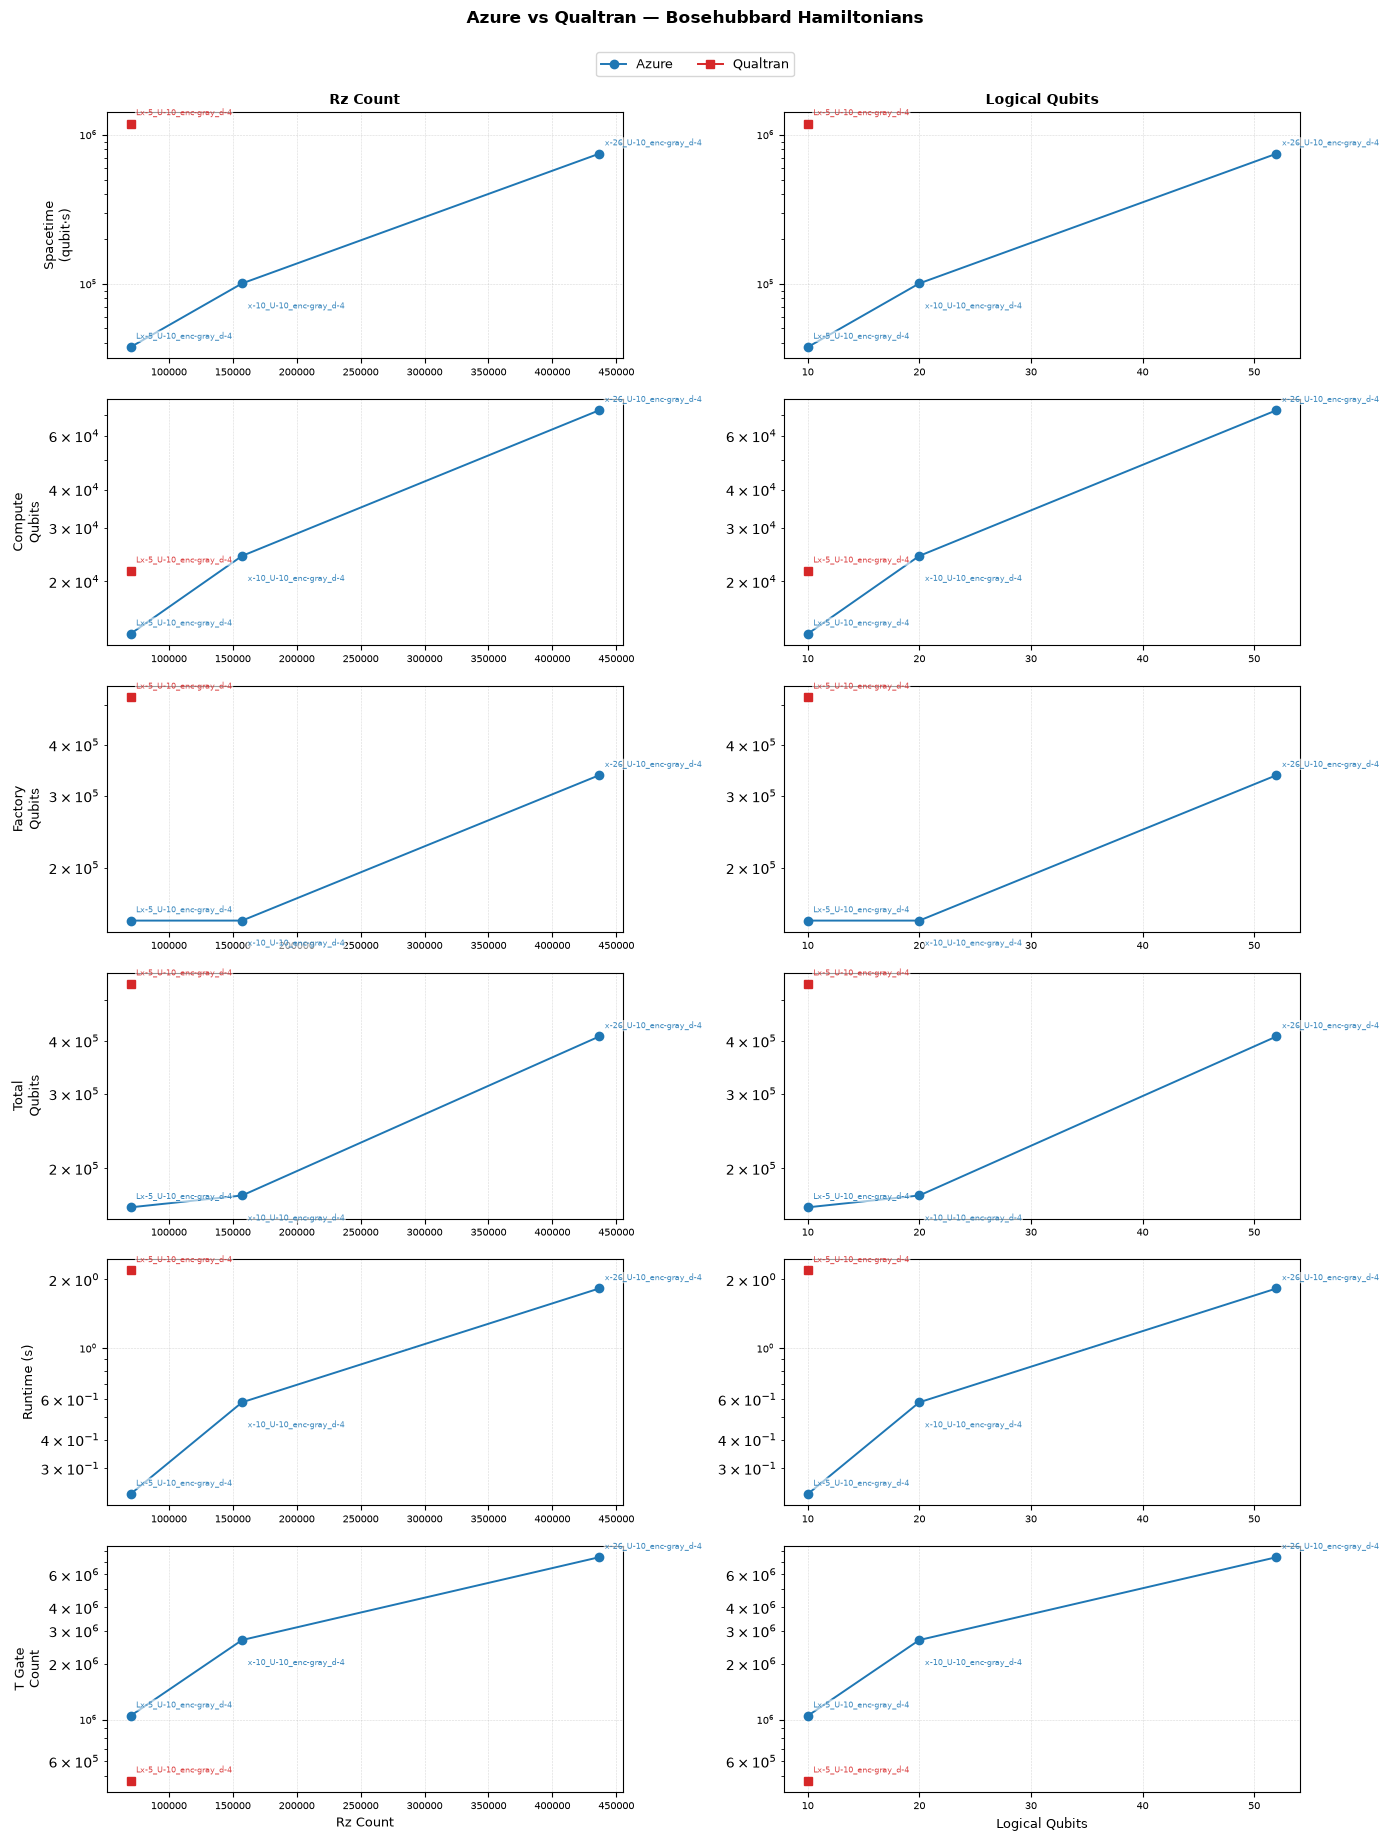

[bosehubbard] Plot saved → /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib/bosehubbard/bosehubbard.png


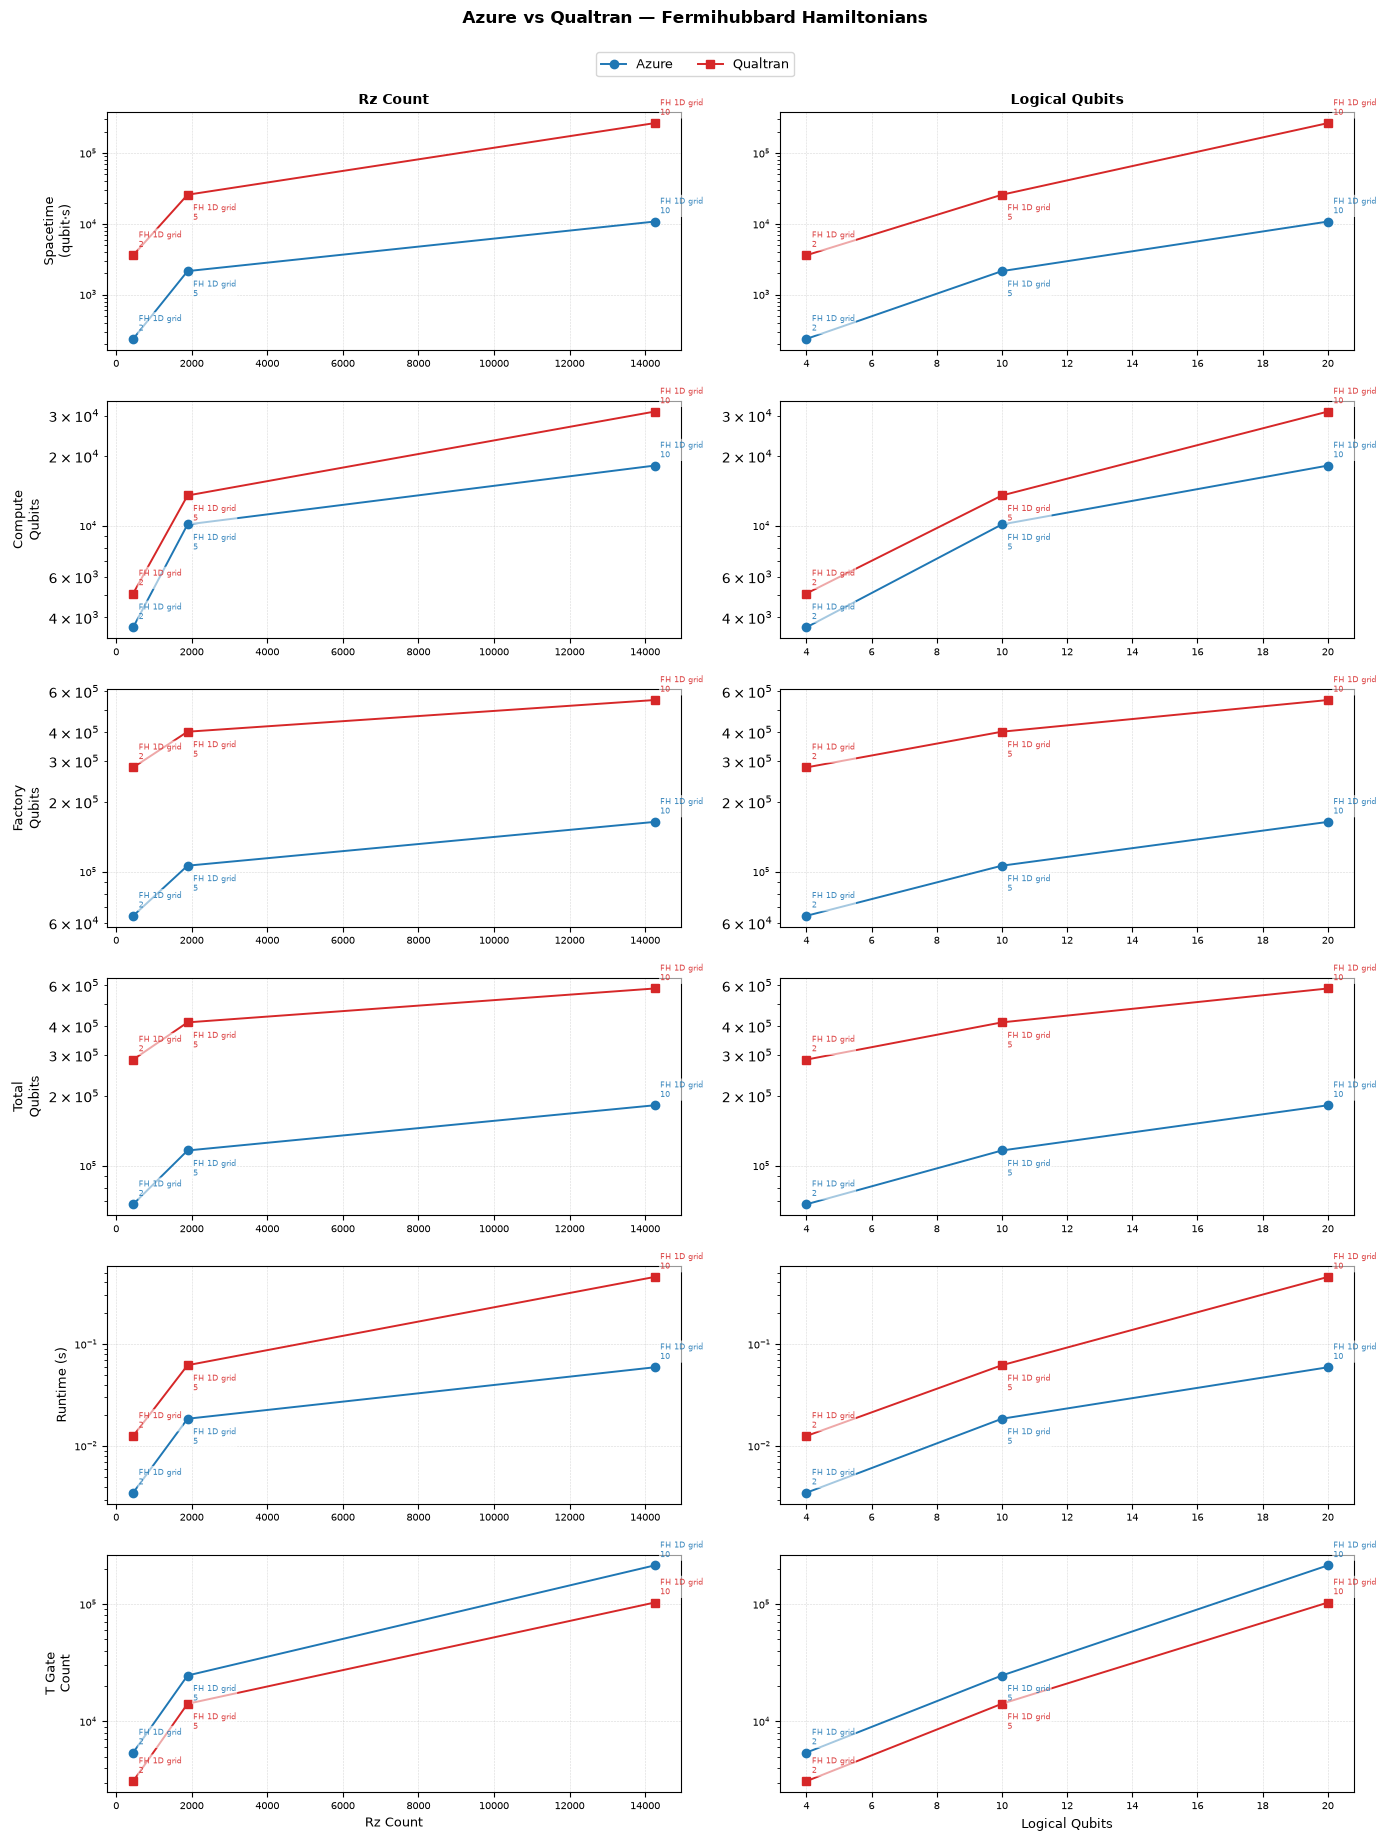

[fermihubbard] Plot saved → /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib/fermihubbard/fermihubbard.png


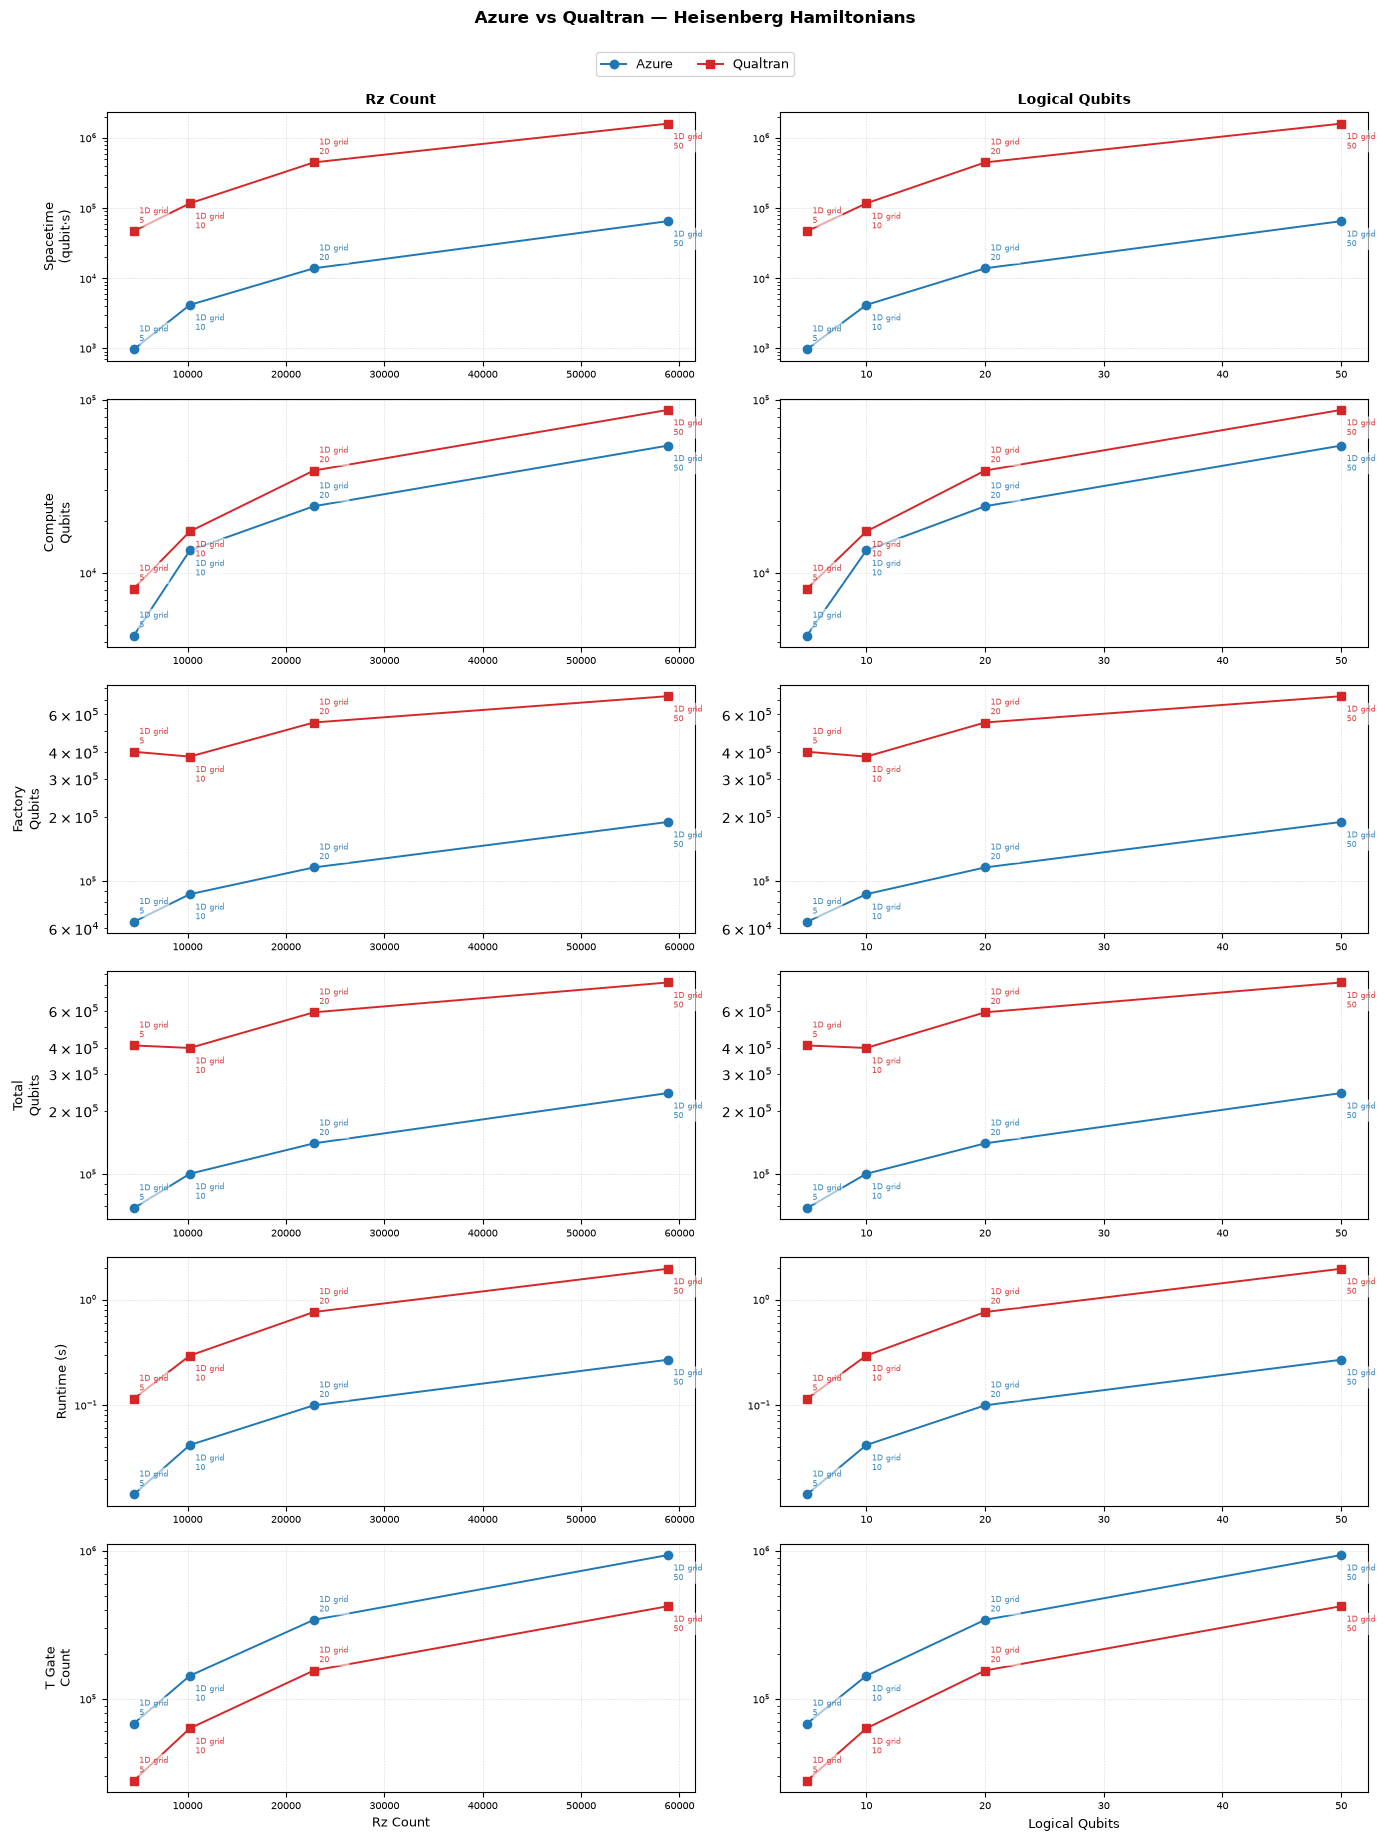

[heisenberg] Plot saved → /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/experiments/05_multi_hamlib/heisenberg/heisenberg.png


In [8]:
# Per-group plots — one figure per problem type, saved under NB_DIR/<group>/
if not combined_df.empty:
    for group, grp_df in combined_df.groupby("group"):
        grp_dir = NB_DIR / group
        grp_dir.mkdir(parents=True, exist_ok=True)

        fig = plot_multi_ham_comparison(
            grp_df,
            figsize=(14, 18),
            title=f"Azure vs Qualtran — {group.capitalize()} Hamiltonians",
            log_y=True,
            annotate_points=True,
        )
        plot_path = grp_dir / f"{group}.png"
        plt.savefig(plot_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[{group}] Plot saved → {plot_path}")

## (Optional) Annotated figure — show Hamiltonian labels

In [9]:
# Uncomment for an annotated version showing ham_key labels on each point:
# if not combined_df.empty:
#     fig2 = plot_multi_ham_comparison(
#         combined_df,
#         figsize=(16, 20),
#         title="Azure vs Qualtran — Annotated",
#         log_y=True,
#         annotate_points=True,
#     )
#     plt.show()
print("(annotated plot cell — uncomment to run)")

(annotated plot cell — uncomment to run)


## Per-Hamiltonian summary table

In [10]:
if not combined_df.empty:
    from IPython.display import display
    import numpy as np

    summary_cols = ["group", "ham_key", "estimator", "rz_count", "logical_qubits",
                    "total_qubits", "compute_qubits", "factory_qubits",
                    "runtime", "t_count", "spacetime"]
    display(combined_df[summary_cols].sort_values(["group", "ham_key", "estimator"]))

    print("\nEstimator coverage per Hamiltonian:")
    pivot = combined_df.pivot_table(
        index=["group", "ham_key"],
        columns="estimator",
        values="total_qubits",
        aggfunc="first",
    )
    display(pivot)

,group,ham_key,estimator,rz_count,logical_qubits,total_qubits,compute_qubits,factory_qubits,runtime,t_count,spacetime
8,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-10_enc-gray_d-4,Azure,157290,20,172526,24246,148280,0.5822,2673930,1.004e+05
9,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-26_U-10_enc-gray_d-4,Azure,436650,52,409746,72702,337044,1.827,7423050,7.486e+05
6,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-10_enc-gray_d-4,Azure,69990,10,161750,13470,148280,0.2315,1049850,3.745e+04
7,bosehubbard,bh_graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-10_enc-gray_d-4,Qualtran,69990,10,545940,21660,524280,2.189,471240,1.195e+06
4,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk,Azure,14250,20,182078,18198,163880,0.0592,213750,1.078e+04
5,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk,Qualtran,14250,20,581706,31212,550494,0.4533,103020,2.637e+05
0,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk,Azure,450,4,68015,3615,64400,0.003504,5400,238.3
1,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk,Qualtran,450,4,286780,5070,281710,0.01258,3080,3609
2,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-0_enc-parity,Azure,1890,10,116150,10110,106040,0.01856,24570,2156
3,fermihubbard,fh-graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-0_enc-parity,Qualtran,1890,10,415290,13500,401790,0.06204,14100,2.576e+04



Estimator coverage per Hamiltonian:


estimator                                                                   Azure  \
group        ham_key                                                                
bosehubbard  bh_graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-10_enc-gray_d-4 1.725e+05   
             bh_graph-1D-grid-nonpbc-qubitnodes_Lx-26_U-10_enc-gray_d-4 4.097e+05   
             bh_graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-10_enc-gray_d-4  1.618e+05   
fermihubbard fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk       1.821e+05   
             fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk         6.802e+04   
             fh-graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-0_enc-parity     1.162e+05   
heisenberg   graph-1D-grid-nonpbc-qubitnodes_Lx-10_h-0                  1.002e+05   
             graph-1D-grid-nonpbc-qubitnodes_Lx-20_h-2                  1.399e+05   
             graph-1D-grid-nonpbc-qubitnodes_Lx-50_h-0.5                 2.43e+05   
             graph-1D-grid-nonpbc-qubitnodes_Lx-5_h-0                   6.874e+04   

estimator                                                                Qualtran  
group        ham_key                                                               
bosehubbard  bh_graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-10_enc-gray_d-4       NaN  
             bh_graph-1D-grid-nonpbc-qubitnodes_Lx-26_U-10_enc-gray_d-4       NaN  
             bh_graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-10_enc-gray_d-4  5.459e+05  
fermihubbard fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk       5.817e+05  
             fh-graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-0_enc-bk         2.868e+05  
             fh-graph-1D-grid-nonpbc-qubitnodes_Lx-5_U-0_enc-parity     4.153e+05  
heisenberg   graph-1D-grid-nonpbc-qubitnodes_Lx-10_h-0                  3.987e+05  
             graph-1D-grid-nonpbc-qubitnodes_Lx-20_h-2                  5.895e+05  
             graph-1D-grid-nonpbc-qubitnodes_Lx-50_h-0.5                8.181e+05  
             graph-1D-grid-nonpbc-qubitnodes_Lx-5_h-0                   4.099e+05

## Single-Hamiltonian detailed comparison

The original per-Hamiltonian step-by-step workflow still works — see
`pipeline.run()` with `run_azure=True, run_qualtran=True` for a single
`PipelineConfig`, then use `compare.metrics.compare()` and
`compare.tables.comparison_dataframe()` for the full side-by-side table.

In [11]:
# Example: run single-Hamiltonian detailed comparison
# Uncomment and set hdf5_path + key_index:
#
# from resourceEstimationPipeline import pipeline
# from resourceEstimationPipeline.compare.metrics import compare, enrich_from_circuit
# from resourceEstimationPipeline.compare.tables import comparison_dataframe
# from resourceEstimationPipeline.config import PipelineConfig, HamlibConfig
#
# single_cfg = PipelineConfig(
#     hamlib=HamlibConfig(
#         hdf5_path=os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "bosehubbard", "BH_D-1_d-4.hdf5"),
#         key_index=30,
#     ),
#     evolution=base_cfg.evolution,
#     transpile=base_cfg.transpile,
#     azure=base_cfg.azure,
#     qualtran=base_cfg.qualtran,
# )
# pr = pipeline.run(single_cfg, run_azure=True, run_qualtran=True)
# if pr.azure_result and pr.clifford_t_circuit:
#     pr.azure_result = enrich_from_circuit(pr.azure_result, pr.clifford_t_circuit)
# if pr.qualtran_result and pr.clifford_t_circuit:
#     pr.qualtran_result = enrich_from_circuit(pr.qualtran_result, pr.clifford_t_circuit)
# report = compare(pr.available_results())
# display(comparison_dataframe(report))
# print("(single-Hamiltonian cell — uncomment to run)")